In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, LeavePOut

In [8]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/4-Algerian_forest_fires_dataset.csv")

In [9]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [13]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire
246,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [ ]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [12]:
df.shape

(247, 14)

In [18]:
df["month"].unique()

array(['6', '7', '8', '9', nan, 'month'], dtype=object)

In [43]:
df = df.drop(index=124)

In [44]:
df["month"].unique()

array(['6', '7', '8', '9', nan], dtype=object)

In [49]:
df = df.dropna()

In [51]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

In [62]:
df["month"].unique()

array([6, 7, 8, 9])

In [58]:
df["month"] = df["month"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.

In [60]:
df["month"] = df["month"].astype(int)

In [66]:
df["day"].unique()
df["day"] = df["day"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["day"] = df["day"].astype(int)

AttributeError: Can only use .str accessor with string values!

In [87]:
df["year"].unique()
df["year"] = df["year"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["year"] = df["year"].astype(int)

In [67]:
df["Temperature"].unique()
df["Temperature"] = df["Temperature"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["Temperature"] = df["Temperature"].astype(int)

In [72]:
df = df.rename(columns={" RH": "RH"})

In [73]:
df["RH"].unique()
df["RH"] = df["RH"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["RH"] = df["RH"].astype(int)

In [75]:
df = df.rename(columns={" Ws": "Ws"})
df["Ws"].unique()
df["Ws"] = df["Ws"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["Ws"] = df["Ws"].astype(int)

In [ ]:
df = df.rename(columns={"Rain ": "Rain"})
df["Rain"].unique()
df["Rain"] = df["Rain"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["Rain"] = df["Rain"].astype(float)

In [80]:
df["FFMC"].unique()
df["FFMC"] = df["FFMC"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["FFMC"] = df["FFMC"].astype(float)

In [81]:
df["DMC"].unique()
df["DMC"] = df["DMC"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["DMC"] = df["DMC"].astype(float)

In [83]:
df["ISI"].unique()
df["ISI"] = df["ISI"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["ISI"] = df["ISI"].astype(float)

In [84]:
df["BUI"].unique()
df["BUI"] = df["BUI"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["BUI"] = df["BUI"].astype(float)

In [85]:
df["FWI"].unique()
df["FWI"] = df["FWI"].str.strip() #başta veya sonda boşluk kaldısya bunu düzeltir.
df["FWI"] = df["FWI"].astype(float)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 28.5+ KB


In [ ]:
### yukarıdaki yöntemlerin aşağıdaki kısa yolu bu şekilde.

int_cols = ["day", "month", "year", "Temperature", "RH", "Ws"]
float_cols = ["Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]

df[int_cols + float_cols] = df[int_cols + float_cols].apply(lambda col: col.str.strip())
df[int_cols] = df[int_cols].astype(int)
df[float_cols] = df[float_cols].astype(float) 

In [89]:
df["FWI"].describe()

count    243.000000
mean       7.035391
std        7.440568
min        0.000000
25%        0.700000
50%        4.200000
75%       11.450000
max       31.100000
Name: FWI, dtype: float64

<Axes: xlabel='FWI', ylabel='Count'>

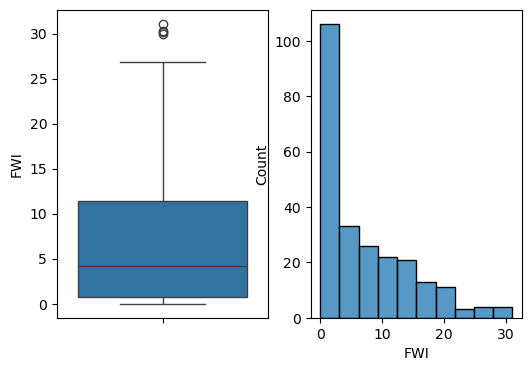

In [ ]:
plt.figure(figsize=(6, 4))
plt.subplot(1,2,1)
sns.boxplot(df["FWI"])
plt.subplot(1,2,2)
sns.histplot(df["FWI"])

In [97]:
""" 
Temperature vs FWI
RH vs FWI
Rain vs FWI
FFMC vs FWI

"""

' \nTemperature vs FWI\nRH vs FWI\nRain vs FWI\nFFMC vs FWI\n\n'

In [109]:
df["Classes"] = df["Classes  "].str.strip()

In [110]:
df["Classes"].unique()

array(['not fire', 'fire'], dtype=object)

In [114]:
df = df.drop(columns=["Classes ", "Classes  "])

In [118]:
df = pd.get_dummies(data= df, columns= ["Classes"], drop_first= True)

<Axes: xlabel='Temperature', ylabel='FWI'>

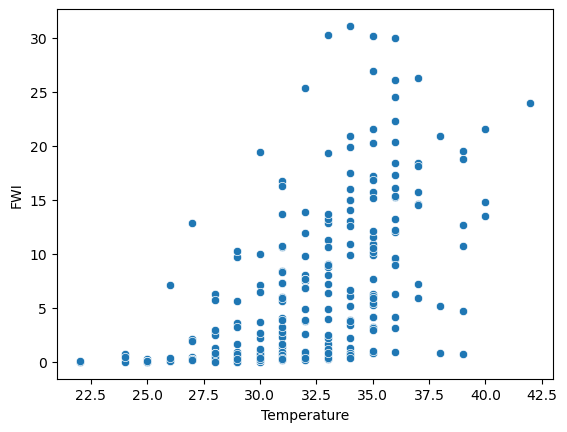

In [138]:
sns.scatterplot(x = df["Temperature"], y = df["FWI"])

<Axes: xlabel='RH', ylabel='FWI'>

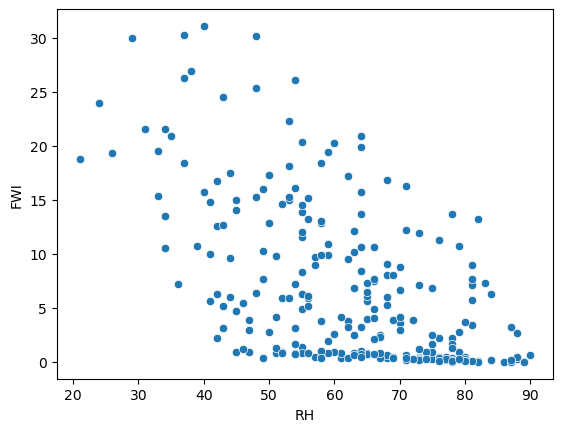

In [132]:
sns.scatterplot(x = df["RH"], y = df["FWI"])

<Axes: xlabel='Rain', ylabel='FWI'>

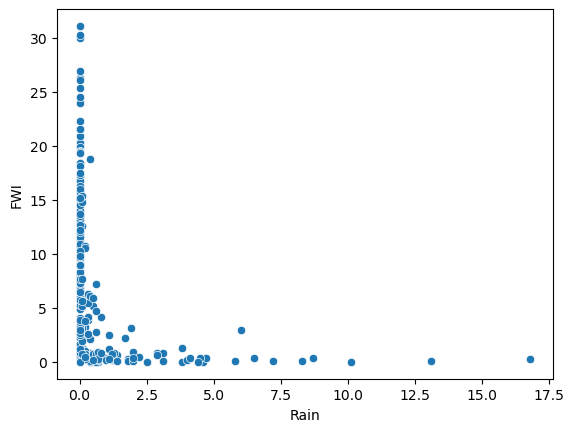

In [135]:
sns.scatterplot(x = df["Rain"], y = df["FWI"])

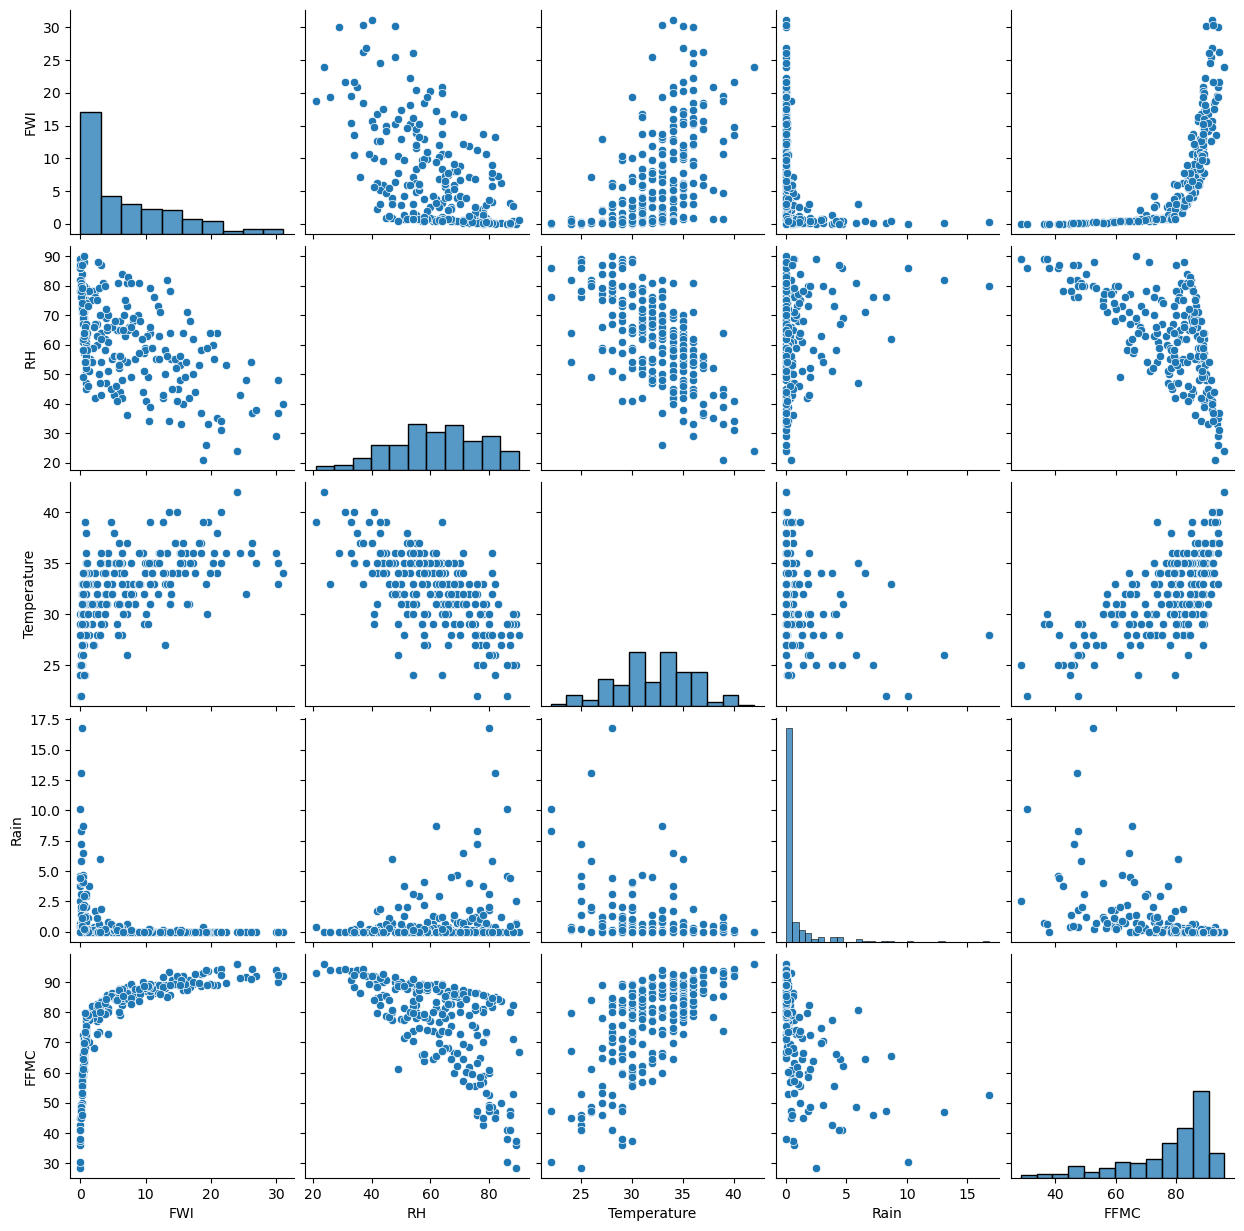

In [141]:
sns.pairplot(df, vars=["FWI", "RH", "Temperature", "Rain", "FFMC"])

<Axes: >

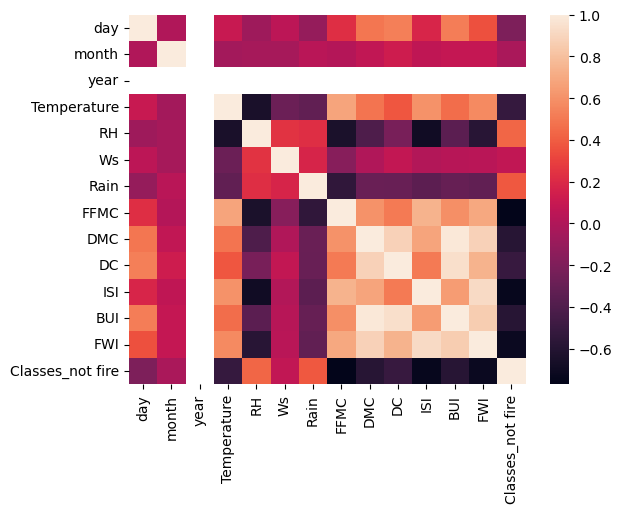

In [ ]:
sns.heatmap(df.corr(),)

In [149]:
X = df[["Temperature", "RH", "Ws", "Rain"]]
y = df["FWI"]

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, train_size=0.8
)

In [151]:
scaler = StandardScaler()

In [152]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [153]:
regression = LinearRegression()

In [154]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [155]:
y_pred = regression.predict(X_test)

In [157]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

In [158]:
print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  3.8176890917523694
mse:  21.449151251974524
score:  0.29230391433246816


In [161]:
regression.coef_

array([ 2.56494974, -3.06030591,  1.93844739, -1.47711907])

In [162]:
regression.intercept_

np.float64(7.420103092783506)

In [160]:
df["FWI"].describe()

count    243.000000
mean       7.035391
std        7.440568
min        0.000000
25%        0.700000
50%        4.200000
75%       11.450000
max       31.100000
Name: FWI, dtype: float64

In [163]:
X = df[["Temperature", "RH", "Ws", "Rain"]]
y = df["FWI"]

In [224]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, train_size=0.8
)

In [225]:
poly = PolynomialFeatures(degree=2)

In [212]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [226]:
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [227]:
regression.fit(X_train_poly_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [228]:
y_pred_poly = regression.predict(X_test_poly_scaled)


In [229]:
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred_poly)

print("mae:", mae)
print("mse:", mse)
print("rmse:", rmse)
print("r2:", score)

mae: 22.775756090532457
mse: 8617.81530747863
rmse: 92.83218896201161
r2: -283.33731892057654


In [231]:
rigde = Ridge(alpha=1.0)

In [236]:
rigde.fit(X_train_poly_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [238]:
y_pred_ridge = rigde.predict(X_test_poly_scaled)

In [239]:
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
score = r2_score(y_test, y_pred_ridge)

In [240]:
print("mae: ", mae)
print("mse: ", mse)
print("score: ", score)

mae:  3.451576387728262
mse:  32.560311683295666
score:  -0.07429915784019281
